# 🎯 Risk-Controlling Prediction Sets (RCPS) with puncc

In this tutorial, we illustrate **Risk-Controlling Prediction Sets (RCPS)** — a
generalization of conformal prediction that controls a *user-defined risk*
(not just miscoverage) at a user-specified level $\alpha$, with confidence
$1-\delta$. RCPS is introduced in Bates, Angelopoulos, Lei, Malik & Jordan
(2021), *"Distribution-Free, Risk-Controlling Prediction Sets"*.

We work entirely with **synthetic data** so the guarantee can be checked
against a known ground truth, and reproduce the paper's flagship setting
(§5.1): multi-class classification with a *class-varying loss*, where
missing some classes from the prediction set is costlier than missing
others (think: missing a rare, severe diagnosis is worse than missing a
common, benign one).

**Table of contents**

- [🎲 Synthetic multi-class data](#data)
- [⚖️ A class-varying loss](#loss)
- [🎯 The set-valued predictor](#predictor)
- [✂️ Calibration / test split](#split)
- [⚙️ Calibrating RCPS](#calibrate)
- [🔮 Predicting prediction sets](#predict)
- [📊 Visualizing prediction sets](#viz)
- [🥊 Comparing UCB methods](#methods)
- [🔁 Does RCPS really control the risk?](#verify)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)

In [1]:
# !pip install puncc

import numpy as np
import matplotlib.pyplot as plt

from deel.puncc.api.RCPS import RCPS

rng = np.random.default_rng(0)

# The WSR bound's running product can overflow to +inf for some lambda
# values -- this is harmless (it correctly signals ">1/delta"), so we
# silence the resulting numpy warning to keep the output clean below.
np.seterr(over="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## 🎲 Synthetic multi-class data <a class="anchor" id="data"></a>

We simulate a classification problem with `n_classes = 6`. For each sample
$i$:

1. Draw a **true** class-probability vector $p_i$ from a Dirichlet
   distribution with a fixed, asymmetric concentration — some classes are
   inherently more common than others.
2. Draw the **true label** $y_i \sim \\text{Categorical}(p_i)$.
3. Simulate an **imperfect model** by adding Gaussian noise to
   $\\log(p_i)$ and re-normalizing with a softmax — this "model" score
   array is what a real trained classifier's output would look like:
   correlated with the truth, but not identical to it. This imperfection
   is exactly *why* we need prediction *sets* rather than single point
   predictions.

In [2]:
N_CLASSES = 6
ALPHA_CONC = np.array([5.0, 3.0, 2.0, 1.0, 1.0, 1.0])  # asymmetric: some classes rarer than others
SIGMA = 0.3  # noise level of the (imperfect) synthetic model


def generate_synthetic_scores(n_samples, n_classes, alpha_conc, sigma, rng):
    """Generate (scores, labels, true_probabilities) for a synthetic
    multi-class classification problem with a known ground truth."""
    p_true = rng.dirichlet(alpha_conc, size=n_samples)
    labels = np.array([rng.choice(n_classes, p=p_true[i]) for i in range(n_samples)])
    logits = np.log(p_true + 1e-6) + rng.normal(0, sigma, size=p_true.shape)
    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    scores = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    return scores, labels, p_true


N_TOTAL = 4000
scores_all, labels_all, p_true_all = generate_synthetic_scores(
    N_TOTAL, N_CLASSES, ALPHA_CONC, SIGMA, rng
)

print("scores_all shape:", scores_all.shape)
print("labels_all shape:", labels_all.shape)
print("class balance:", np.round(np.bincount(labels_all, minlength=N_CLASSES) / N_TOTAL, 3))

scores_all shape: (4000, 6)
labels_all shape: (4000,)
class balance: [0.374 0.238 0.158 0.08  0.071 0.079]


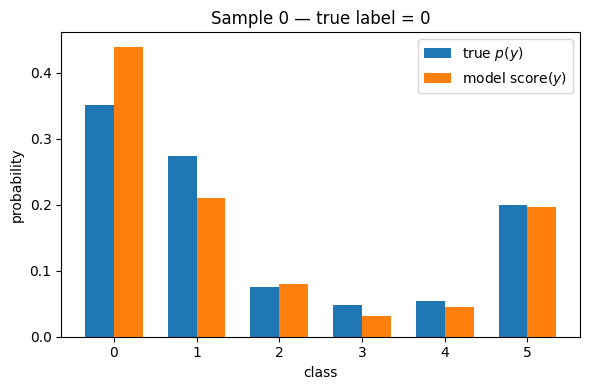

In [3]:
# Compare one sample's true probabilities to its noisy model score
sample = 0
x = np.arange(N_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, p_true_all[sample], width, label="true $p(y)$")
ax.bar(x + width / 2, scores_all[sample], width, label="model score$(y)$")
ax.set_xlabel("class")
ax.set_ylabel("probability")
ax.set_xticks(x)
ax.legend()
ax.set_title(f"Sample {sample} — true label = {labels_all[sample]}")
fig.tight_layout()
plt.show()

## ⚖️ A class-varying loss <a class="anchor" id="loss"></a>

Standard conformal prediction controls *miscoverage* — the probability
that the true label is missing from the prediction set — treating every
class as equally important to catch. RCPS lets us control a richer,
**user-defined** risk instead.

Following the paper's own example (a doctor screening for diagnoses of
different severity), imagine each class carries a different **cost of
being missed** $L_y$ — e.g. missing a rare, severe condition is worse
than missing a common, benign one. We draw these costs once, fixed and
independent of any particular sample, and define the loss of a prediction
set $S$ for a true label $y$ as:

$$L(y, S) = L_y \\cdot \\mathbb{1}\\{y \\notin S\\}$$

RCPS will calibrate the prediction sets so that the **average** value of
this loss on future data stays below $\\alpha$, with probability
$1-\\delta$.

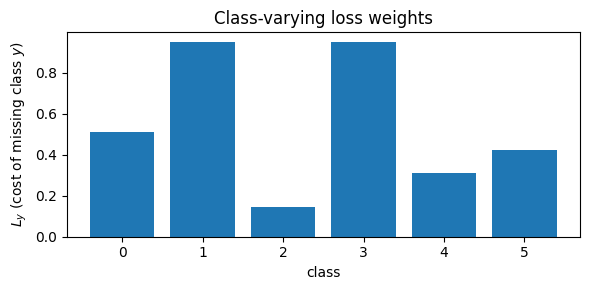

In [4]:
def make_class_weights(n_classes, seed):
    """Cost of missing class y from the prediction set, L_y ~ Uniform(0, 1)."""
    return np.random.default_rng(seed).uniform(0.0, 1.0, size=n_classes)


def weighted_miscoverage_loss(prediction_sets, labels, class_weights):
    """L(y, S) = L_y * 1{y not in S}, for each (S, y) pair."""
    return np.array([
        0.0 if y in S else class_weights[y]
        for S, y in zip(prediction_sets, labels)
    ])


class_weights = make_class_weights(N_CLASSES, seed=1)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(np.arange(N_CLASSES), class_weights)
ax.set_xlabel("class")
ax.set_ylabel("$L_y$ (cost of missing class $y$)")
ax.set_title("Class-varying loss weights")
fig.tight_layout()
plt.show()

## 🎯 The set-valued predictor <a class="anchor" id="predictor"></a>

RCPS calibrates a **family of nested prediction sets** indexed by a
threshold parameter $\lambda$. We use the natural, paper-recommended
family for classification:

$$T_\lambda(x) = \\{y : \\text{score}_x(y) \\geq -\\lambda\\}$$

with $\\lambda \\in [-1, 0]$: $\\lambda = -1$ gives the empty set (nothing
included), and $\\lambda = 0$ includes every class. Larger $\\lambda$
means larger sets — this **nesting** property is what RCPS's calibration
procedure relies on.

`RCPS` expects a model object with a `.predict(X, lam)` method (used
internally) — we also add `__call__(X, lam)` for compatibility with
puncc's `LambdaPredictor` typing protocol.

In [5]:
class LambdaPredictorFromSoftmax:
    """T_lambda(x) = {y : score(y) >= -lambda}, for scores already
    given as a (n_samples, n_classes) numpy array."""

    def predict(self, X, lam):
        return [np.where(row >= -lam)[0] for row in X]

    def __call__(self, X, lam):
        return self.predict(X, lam)


model = LambdaPredictorFromSoftmax()

# Quick sanity check: as lambda grows from -1 to 0, sets grow
print("lambda=-0.8:", model.predict(scores_all[:1], -0.8))
print("lambda=-0.2:", model.predict(scores_all[:1], -0.2))
print("lambda= 0.0:", model.predict(scores_all[:1], 0.0))

lambda=-0.8: [array([], dtype=int64)]
lambda=-0.2: [array([0, 1])]
lambda= 0.0: [array([0, 1, 2, 3, 4, 5])]


## ✂️ Calibration / test split <a class="anchor" id="split"></a>

As with any conformal method, we split our data into a calibration set
(used to choose $\lambda$) and a test set (used to evaluate the result).

In [6]:
N_CALIB = 1500
N_TEST = 1000

scores_calib, labels_calib = scores_all[:N_CALIB], labels_all[:N_CALIB]
scores_test, labels_test = scores_all[N_CALIB:N_CALIB + N_TEST], labels_all[N_CALIB:N_CALIB + N_TEST]

print("calibration set:", scores_calib.shape)
print("test set:", scores_test.shape)

calibration set: (1500, 6)
test set: (1000, 6)


## ⚙️ Calibrating RCPS <a class="anchor" id="calibrate"></a>

We instantiate `RCPS` with our set-valued predictor and loss function, then
calibrate it to control the risk at level $\alpha = 0.1$ with confidence
$1 - \delta = 0.9$.

`RCPS` supports several ways of computing the upper confidence bound (UCB)
on the risk, selected via the `method` argument — `"clt"`,
`"simplified_hoeffding"`, `"tighter_hoeffding"`, `"bentkus"`,
`"hoeffding_bentkus"`, `"bernstein"`, or `"wsr"` (the default, and the
one recommended by the paper). We start with `"wsr"`.

Since our loss function needs the fixed `class_weights` in addition to the
prediction sets and labels, we wrap it in a small closure — `RCPS`
expects a loss function of exactly two arguments,
`loss_function(prediction_sets, labels)`.

---
**NOTE**

   `alpha` must be passed as a plain Python `float` (not a numpy scalar),
   and `lambda_grid` has no default — it must always be supplied
   explicitly.

---

In [7]:
loss_fn = lambda preds, labels: weighted_miscoverage_loss(preds, labels, class_weights)

ALPHA = 0.1
DELTA = 0.1
lambda_grid = np.linspace(-1.0, 0.0, 200)

rcps = RCPS(model=model, loss_function=loss_fn, loss_function_upper_bound=1)
rcps.calibrate(scores_calib, labels_calib, delta=DELTA, method="wsr")

print("Calibration done.")

Calibration done.


## 🔮 Predicting prediction sets <a class="anchor" id="predict"></a>

---
**NOTE**

   `RCPS.predict()` currently returns the prediction sets directly (a
   plain list), not a `(prediction, prediction_set)` pair — don't try to
   unpack it into two variables.

---

In [8]:
prediction_sets = rcps.predict(scores_test, alpha=ALPHA, lambda_grid=lambda_grid)

empirical_risk = weighted_miscoverage_loss(prediction_sets, labels_test, class_weights).mean()
set_sizes = np.array([len(S) for S in prediction_sets])

print(f"Empirical risk on the test set: {empirical_risk:.4f}  (target alpha = {ALPHA})")
print(f"Mean prediction set size: {set_sizes.mean():.2f} (out of {N_CLASSES} classes)")

Empirical risk on the test set: 0.0836  (target alpha = 0.1)
Mean prediction set size: 3.05 (out of 6 classes)


## 📊 Visualizing prediction sets <a class="anchor" id="viz"></a>

Let's look at a few test samples: for each, we show the model's raw
scores, the threshold used, and which classes ended up in the prediction
set.

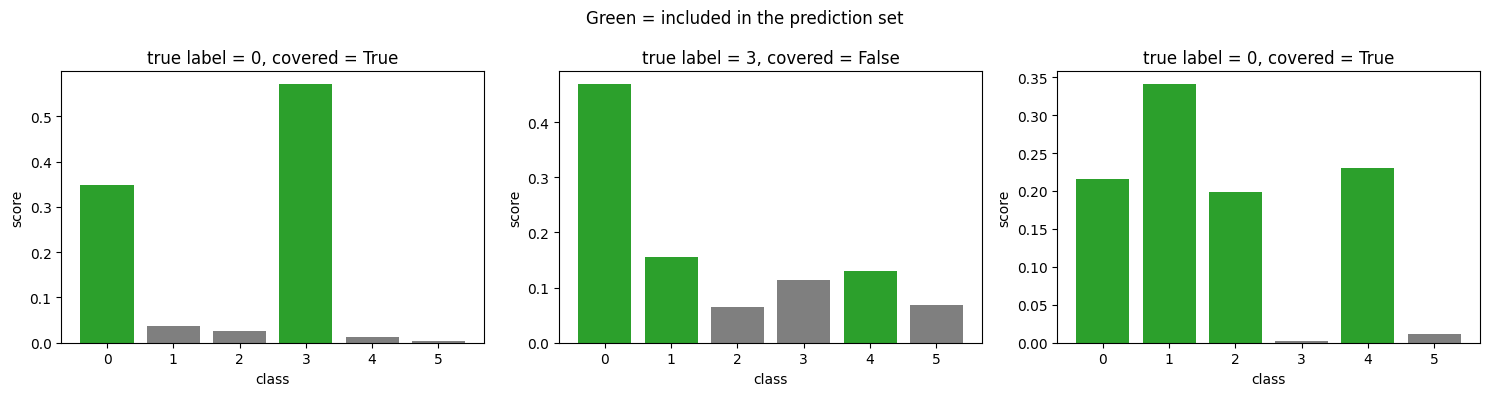

In [9]:
order = np.argsort(set_sizes)
chosen = [order[len(order) // 10], order[len(order) // 2], order[-len(order) // 10]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, s in zip(axes, chosen):
    row = scores_test[s]
    included = np.zeros(N_CLASSES, dtype=bool)
    included[prediction_sets[s]] = True
    colors = ["tab:green" if inc else "tab:gray" for inc in included]
    ax.bar(np.arange(N_CLASSES), row, color=colors)
    covered = labels_test[s] in prediction_sets[s]
    ax.set_title(f"true label = {labels_test[s]}, covered = {covered}")
    ax.set_xlabel("class")
    ax.set_ylabel("score")
fig.suptitle("Green = included in the prediction set")
fig.tight_layout()
plt.show()

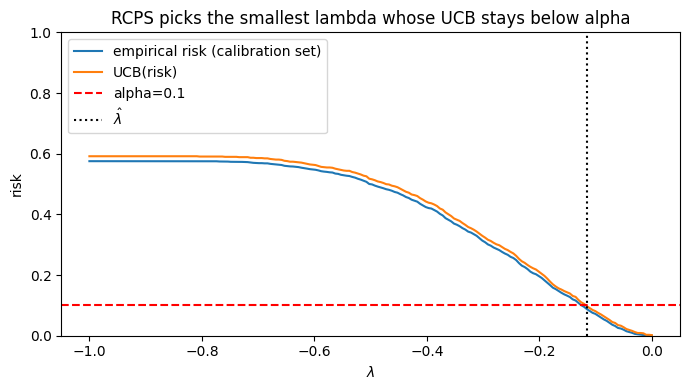

In [10]:
# What is RCPS's calibration actually doing? It scans lambda until the
# UCB on the risk drops below alpha. `rcps.ucb` is the calibrated UCB
# function; we compare it here to the raw (uncorrected) empirical risk.
risk_curve = np.array([
    weighted_miscoverage_loss(model.predict(scores_calib, lam), labels_calib, class_weights).mean()
    for lam in lambda_grid
])
ucb_curve = np.array([rcps.ucb(lam) for lam in lambda_grid])

violation_idx = np.where(ucb_curve >= ALPHA)[0]
lambda_hat = lambda_grid[0] if len(violation_idx) == 0 else lambda_grid[violation_idx[-1] + 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambda_grid, risk_curve, label="empirical risk (calibration set)")
ax.plot(lambda_grid, ucb_curve, label="UCB(risk)")
ax.axhline(ALPHA, color="red", linestyle="--", label=f"alpha={ALPHA}")
ax.axvline(lambda_hat, color="black", linestyle=":", label=r"$\hat\lambda$")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("risk")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("RCPS picks the smallest lambda whose UCB stays below alpha")
fig.tight_layout()
plt.show()

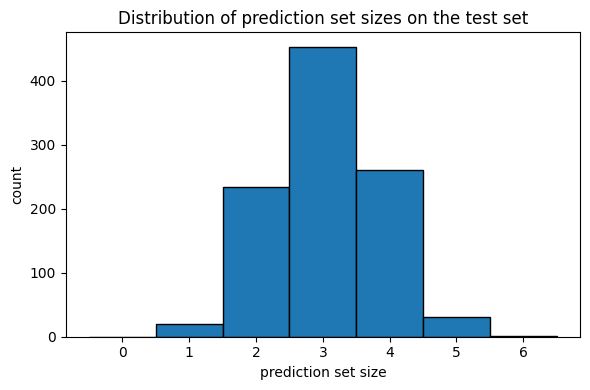

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(set_sizes, bins=np.arange(N_CLASSES + 2) - 0.5, edgecolor="black")
ax.set_xlabel("prediction set size")
ax.set_ylabel("count")
ax.set_title("Distribution of prediction set sizes on the test set")
fig.tight_layout()
plt.show()

## 🥊 Comparing UCB methods <a class="anchor" id="methods"></a>

Different UCB methods trade off tightness for validity differently,
especially with **small calibration sets** — exactly where it matters
most. Let's deliberately calibrate on a *small* calibration set
(`n_calib=150`) with three methods: `"wsr"` (the paper's recommended,
tight, finite-sample-valid bound), `"hoeffding_bentkus"` (also
finite-sample-valid, but more conservative), and `"clt"` (a normal
approximation that is only *asymptotically* valid — it does not carry
the same finite-sample guarantee).

In [12]:
scores_calib_small, labels_calib_small = scores_all[:150], labels_all[:150]
scores_test_cmp, labels_test_cmp = scores_all[2000:3000], labels_all[2000:3000]
lambda_grid_cmp = np.linspace(-1.0, 0.0, 150)

methods_compare = ["wsr", "hoeffding_bentkus", "clt"]
compare_results = {}

for method in methods_compare:
    rcps_m = RCPS(model=model, loss_function=loss_fn, loss_function_upper_bound=1)
    rcps_m.calibrate(scores_calib_small, labels_calib_small, delta=DELTA, method=method)
    preds_m = rcps_m.predict(scores_test_cmp, alpha=ALPHA, lambda_grid=lambda_grid_cmp)
    risk_m = weighted_miscoverage_loss(preds_m, labels_test_cmp, class_weights).mean()
    size_m = np.mean([len(S) for S in preds_m])
    compare_results[method] = (risk_m, size_m)
    print(f"{method:20s}  risk={risk_m:.4f}  mean set size={size_m:.2f}")

wsr                   risk=0.0959  mean set size=2.88


hoeffding_bentkus     risk=0.0553  mean set size=3.55
clt                   risk=0.0838  mean set size=3.08


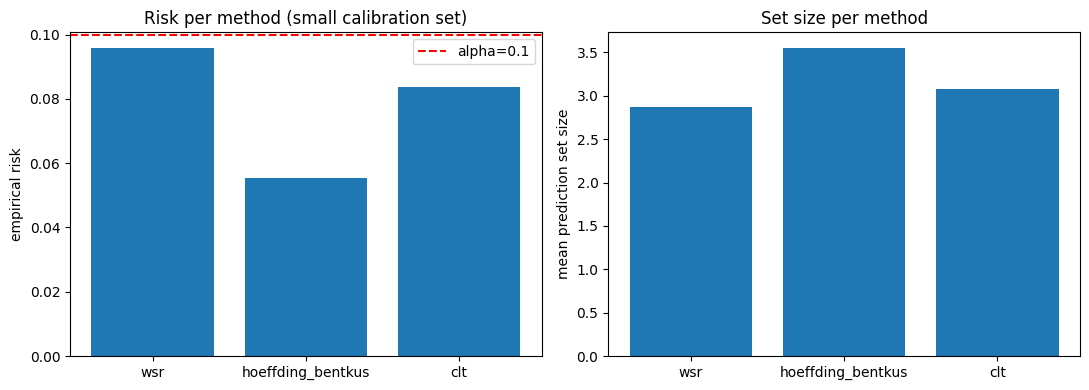

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(compare_results.keys())
risks = [compare_results[m][0] for m in names]
sizes = [compare_results[m][1] for m in names]

axes[0].bar(names, risks)
axes[0].axhline(ALPHA, color="red", linestyle="--", label=f"alpha={ALPHA}")
axes[0].set_ylabel("empirical risk")
axes[0].legend()
axes[0].set_title("Risk per method (small calibration set)")

axes[1].bar(names, sizes)
axes[1].set_ylabel("mean prediction set size")
axes[1].set_title("Set size per method")

fig.tight_layout()
plt.show()

## 🔁 Does RCPS really control the risk? <a class="anchor" id="verify"></a>

The paper's central claim is that, with probability at least $1-\delta$
*over the random draw of the calibration set*, the resulting prediction
sets control the risk at level $\alpha$. A single calibration/test split
can't verify this — we need to repeat the whole calibrate→predict
procedure over many independent draws and look at how often the risk
exceeds $\alpha$.

We restrict this repeated check to `"wsr"` and `"clt"` — the other
methods (`"hoeffding_bentkus"`, `"bentkus"`, `"tighter_hoeffding"`) search
an internal grid of candidate risk values per calibration and are too
slow to repeat hundreds of times here, though they carry the same
finite-sample guarantee as `"wsr"`.

This cell takes about a minute to run.

In [14]:
N_TRIALS = 150
N_CALIB_TRIAL = 100
LAMBDA_GRID_TRIAL = np.linspace(-1.0, 0.0, 30)
METHODS_TRIAL = ["wsr", "clt"]

trial_rng = np.random.default_rng(42)
risks_per_method = {m: [] for m in METHODS_TRIAL}

for trial in range(N_TRIALS):
    tr_scores, tr_labels, _ = generate_synthetic_scores(
        N_CALIB_TRIAL + 300, N_CLASSES, ALPHA_CONC, SIGMA, trial_rng
    )
    tr_scores_calib, tr_labels_calib = tr_scores[:N_CALIB_TRIAL], tr_labels[:N_CALIB_TRIAL]
    tr_scores_test, tr_labels_test = tr_scores[N_CALIB_TRIAL:], tr_labels[N_CALIB_TRIAL:]

    for method in METHODS_TRIAL:
        rcps_t = RCPS(model=model, loss_function=loss_fn, loss_function_upper_bound=1)
        rcps_t.calibrate(tr_scores_calib, tr_labels_calib, delta=DELTA, method=method)
        preds_t = rcps_t.predict(tr_scores_test, alpha=ALPHA, lambda_grid=LAMBDA_GRID_TRIAL)
        risk_t = weighted_miscoverage_loss(preds_t, tr_labels_test, class_weights).mean()
        risks_per_method[method].append(risk_t)

for method in METHODS_TRIAL:
    risks = np.array(risks_per_method[method])
    violations = (risks > ALPHA).sum()
    print(f"{method:5s}: mean risk={risks.mean():.4f}  "
          f"violations={violations}/{N_TRIALS} ({violations / N_TRIALS:.1%}, target delta={DELTA})")

wsr  : mean risk=0.0458  violations=6/150 (4.0%, target delta=0.1)
clt  : mean risk=0.0604  violations=11/150 (7.3%, target delta=0.1)


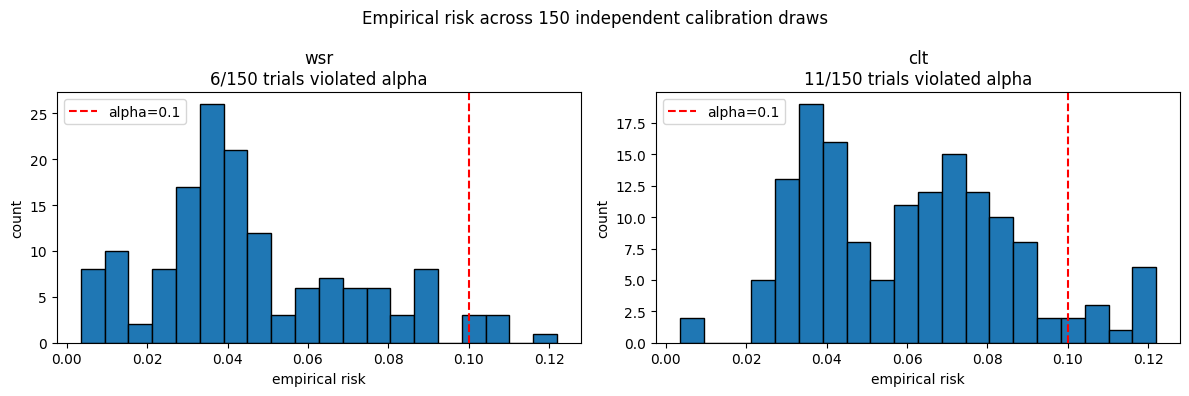

In [15]:
fig, axes = plt.subplots(1, len(METHODS_TRIAL), figsize=(6 * len(METHODS_TRIAL), 4))
for ax, method in zip(axes, METHODS_TRIAL):
    risks = np.array(risks_per_method[method])
    violations = (risks > ALPHA).sum()
    ax.hist(risks, bins=20, edgecolor="black")
    ax.axvline(ALPHA, color="red", linestyle="--", label=f"alpha={ALPHA}")
    ax.set_xlabel("empirical risk")
    ax.set_ylabel("count")
    ax.set_title(f"{method}\n{violations}/{N_TRIALS} trials violated alpha")
    ax.legend()
fig.suptitle(f"Empirical risk across {N_TRIALS} independent calibration draws")
fig.tight_layout()
plt.show()

`"wsr"` carries the paper's finite-sample $(\alpha, \delta)$-RCPS
guarantee for *any* calibration set size — the violation rate above
should stay at or below $\delta = 0.1$ (up to Monte Carlo noise).
`"clt"` is only *asymptotically* valid (as the calibration set grows):
at this small calibration size it typically shows a somewhat higher
violation rate, since it does not carry the same finite-sample guarantee.

# 🎉 Congratulations
**You now know how to control a custom, class-varying risk with RCPS!**

To learn more about how RCPS fits into *puncc*'s general conformal
prediction architecture, check out the
[**Architecture Overview**](puncc_architecture.ipynb) tutorial.